# Classes de Beta-Lactamase (Ambler):

In [1]:
import sys
from pathlib import Path

import re
import pandas as pd
import matplotlib.pyplot as plt

import argos
from argos import ArgosDataset

In [2]:
def encontrar_raiz_repo(marcadores=(".git", "src")):
    """Sobe o diretorio ate achar `.git` (repo real) ou `src/` (funciona tambem
    em sandbox local sem git inicializado) -- mesmo padrao usado nos notebooks
    da disciplina/repo original, generalizado pra cobrir os 2 casos."""
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if any((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei nenhum de {marcadores} subindo a partir de {caminho}")


RAIZ = encontrar_raiz_repo()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

In [4]:
from src.features_amr import AmblerClassifier, anotar_resistoma

pd.set_option("display.max_colwidth", 160)

## 1. A tabela de referencia (`Tabela_Beta_Lactamases_e_Resistencia.xlsx`)

3 abas:

- **`Ambler & Resistoma`** -- 1 linha por (classe de Ambler, subgrupo): quais genes/familias (nomenclatura BLDB),
  o que o grupo hidrolisa, o que ainda funciona contra ele, status dos inibidores classicos vs. novos, especies
  onde predomina.
- **`Inibidores (BLIs)`** -- 1 linha por inibidor (clavulanato, tazobactam, avibactam, ...): contra qual classe
  ele funciona ou nao, e a associacao comercial.
- **`Matriz por Especie`** -- 1 linha por especie prioritaria da OMS: presenca esperada de cada classe naquela
  especie especificamente (ex.: KPC e "altissima frequencia" em *K. pneumoniae*, "raro" em *A. baumannii*).

In [12]:
xlsx_path =  "../data/raw/Tabela_Beta_Lactamases_e_Resistencia.xlsx"

ambler_ref = pd.read_excel(xlsx_path, sheet_name="Ambler & Resistoma")
ambler_ref

,Classe de Ambler / Subgrupo,Genes / Famílias (BLDB),Resiste a quais Beta-Lactâmicos? (Hidrolisa),Opções Eficazes (Não Hidrolisado / Destrói o Patógeno),Status dos Inibidores (Funcional vs Inoperante),Espécies Predominantes
0,Classe A — ESBLs Clássicas,"CTX-M (CTX-M-15/2/14/27), TEM (TEM-10/26), SHV (SHV-2/5/12), PER, VEB, GES-1",Cefalosporinas (1ª a 4ª geração) e Monobactâmicos (Aztreonam),"Carbapenêmicos (Meropenem, Imipenem, Ertapenem) e Cefiderocol","Funcionais: Clavulanato, Tazobactam, Sulbactam, Avibactam, Vaborbactam, Relebactam","E. coli, K. pneumoniae, Enterobacter spp., P. aeruginosa, A. baumannii"
1,Classe A — Serino-Carbapenemases,"KPC (KPC-2/3/40+), GES (GES-2/5/20), SME, IMI, NMC-A, SFC","TODOS os beta-lactâmicos: Cefalosporinas, Monobactâmicos (Aztreonam) e Carbapenêmicos (Meropenem, Imipenem, Ertapenem)","Associações Beta-Lactâmico + Novo Inibidor: Ceftazidima-Avibactam, Meropenem-Vaborbactam, Imipenem-Relebactam","Funcionais: Avibactam, Vaborbactam, Relebactam\nInoperantes: Clavulanato e Tazobactam","K. pneumoniae (ST258/307), E. coli, Enterobacter spp., Serratia marcescens"
2,Classe B — MBLs Adquiridas,"NDM (NDM-1/5), VIM (VIM-1/2), IMP (IMP-1/4/13), SPM-1, GIM","Cefalosporinas (1ª a 4ª gen) e Carbapenêmicos (Meropenem, Imipenem, Ertapenem)","Monobactâmicos (Aztreonam) - MBLs NÃO hidrolisam Aztreonam. Se co-produzir ESBL, usa-se Aztreonam + Avibactam; Cefiderocol","Funcionais: Quelantes de Zinco (in vitro: EDTA, Aspergillomarasmine)\nInoperantes: Nenhum BLI clínico aprovado isolado (Clavulanato, Avibactam, Vaborbactam,...","K. pneumoniae, E. coli, P. aeruginosa, A. baumannii, Enterobacter spp."
3,Classe B — MBLs Cromossômicas / Específicas,"CphA (Aeromonas), L1 (S. maltophilia), Bla2 (Bacillus)",Carbapenêmicos (CphA hidrolisa carbapenêmicos de forma seletiva),Monobactâmicos (Aztreonam) para CphA e L1,Funcionais: EDTA\nInoperantes: Todos os inibidores de serino-beta-lactamases,"Aeromonas spp. (CphA), Stenotrophomonas maltophilia (L1), Bacillus spp."
4,Classe C — Cefalosporinases (AmpC),"AmpC, CMY (CMY-2), DHA, FOX, MOX, MIR, PDC (Pseudomonas), ADC (Acinetobacter)","Cefalosporinas (1ª a 3ª gen), Cefamicinas (Cefoxitina) e Monobactâmicos (Aztreonam)","Carbapenêmicos (Meropenem, Imipenem), Cefalosporina de 4ª gen (Cefepima) e Cefiderocol","Funcionais: Avibactam, Vaborbactam, Relebactam\nInoperantes: Clavulanato, Sulbactam, Tazobactam","Enterobacter cloacae, Citrobacter freundii, Serratia marcescens, P. aeruginosa, A. baumannii, E. coli"
5,Classe D — OXA Penicilinases (Estreito),"OXA-1, OXA-2, OXA-10","Penicilinas (Oxacilina). Poupam cefalosporinas de 3ª/4ª gen, monobactâmicos e carbapenêmicos","Carbapenêmicos, Cefalosporinas de 3ª/4ª gen e Monobactâmicos",Funcionais: Avibactam\nInoperantes: Inibidores clássicos (parcialmente),"E. coli, P. aeruginosa, K. pneumoniae"
6,Classe D — OXA Carbapenemases (Enterobacterales),"OXA-48-like (OXA-48, OXA-181, OXA-232, OXA-162)",Carbapenêmicos (hidrólise moderada). POUPAM Cefalosporinas de 3ª/4ª gen e Monobactâmicos,"Cefalosporinas de 3ª/4ª geração (Ceftazidima, Cefepima) e Monobactâmicos (Aztreonam) (quando sem ESBL)","Funcionais: Avibactam (Ceftazidima-Avibactam é escolha)\nInoperantes: Clavulanato, Tazobactam, Vaborbactam, Relebactam","K. pneumoniae, E. coli, Enterobacter spp."
7,Classe D — OXA Carbapenemases (Acinetobacter),"OXA-23-like, OXA-24/40-like, OXA-58-like, OXA-51-like (cromossômica)",Carbapenêmicos e Cefalosporinas em Acinetobacter,"Sulbactam-Durlobactam, Cefiderocol, Colistina, Tigeciclina, Eravacyclina","Funcionais: Durlobactam\nInoperantes: Clavulanato, Tazobactam, Avibactam, Vaborbactam",Acinetobacter baumannii


In [13]:
inibidores = pd.read_excel(xlsx_path, sheet_name="Inibidores (BLIs)")
inibidores

,Inibidor / Classe,Estrutura Química,Inibe Classe A (ESBL)?,Inibe Classe A (KPC)?,Inibe Classe B (MBL)?,Inibe Classe C (AmpC)?,Inibe Classe D (OXA-48)?,Associação Comercial / Aplicação Clínico-Epidemiológica
0,Clavulanato,Beta-lactâmico,Sim,Não,Não,Não,Não,Amoxicilina + Clavulanato
1,Tazobactam,Penicilina sulfona,Sim,Não,Não,Não,Não,"Piperacilina + Tazobactam, Ceftolozana + Tazobactam"
2,Avibactam,Diazabicyclooctano (DBO),Sim,Sim,Não,Sim,Sim,Ceftazidima + Avibactam (Jycata/Avycaz)
3,Vaborbactam,Boronato cíclico,Sim,Sim,Não,Sim,Não,Meropenem + Vaborbactam (Vaborem)
4,Relebactam,Diazabicyclooctano (DBO),Sim,Sim,Não,Sim,Não,Imipenem + Cilastatina + Relebactam (Recarbrio)
5,Durlobactam,Diazabicyclooctano (DBO),Sim,Sim,Não,Sim,Sim (Acinetobacter),Sulbactam + Durlobactam (Xacduro)
6,EDTA / Aspergillomarasmine,Quelante de Zn2+,Não,Não,Sim (in vitro),Não,Não,Uso experimental / diagnóstico laboratorial


In [14]:
matriz_especie = pd.read_excel(xlsx_path, sheet_name="Matriz por Espécie")
matriz_especie


,Espécie Prioritária (OMS Crítico),Gram,MBL (Classe B: NDM/VIM/IMP),Serino-Carbapenemase (Classe A: KPC),ESBL (Classe A: CTX-M/SHV/TEM),AmpC (Classe C),OXA Carbapenemase (Classe D),Aztreonam (Monobactâmico) Sensível?
0,Klebsiella pneumoniae,Gram-negativa,Presente (plasmidial),Altíssima frequência (KPC-2/3 em ST258/307),Altíssima frequência (CTX-M-15),Plasmidial (CMY/DHA),Altíssima frequência (OXA-48-like),Apenas se MBL isolada (sem ESBL/AmpC)
1,Escherichia coli,Gram-negativa,Presente (NDM-1/5),Presente (frequência média),Altíssima frequência (CTX-M-14/15),Cromossômica (baixo nível) / Plasmidial,Presente (OXA-48-like),Apenas se MBL isolada
2,Enterobacter cloacae complex,Gram-negativa,Presente (NDM/VIM),Presente (KPC/IMI),Alta frequência,Constitutiva / Induzível (AmpC cromossômica),Presente (OXA-48-like),Geralmente Resistente (hidrolisado por AmpC)
3,Acinetobacter baumannii,Gram-negativa,Presente (NDM-1),Raro,Presente (PER/VEB),Cromossômica (blaADC),Altíssima frequência (OXA-23/24/58/51),Resistente (porinas/efluxo e AmpC/ADC)
4,Pseudomonas aeruginosa,Gram-negativa,Alta prevalência (VIM/IMP),Emergente (KPC),Presente (PER/VEB/GES),Constitutiva / Induzível (PDC/AmpC),Presente (OXA-50 / OXA-48-like),Sensível se apenas MBL; Resistente se AmpC/Efluxo


## 2. Carregando o resistoma

In [16]:
metadata = pd.read_csv("../data/processed/metadata_filtrada.csv")
metadata.head()

,Species,Source,Date,Location,sample,BioSample,Estado,Região,source_type,WHO_Priority
0,Leptospira interrogans,Homo sapiens,NaN,Salvador,GCA_000216055.2,SAMN00254327,BA,Nordeste,Other,Other
1,Escherichia coli,NaN,1990.0,Brazil,GCA_000316425.1,SAMN01041333,NaN,NaN,Unknown,Critical
2,Vibrio cholerae,patient with cholera-like diarrhea,1991.0,NaN,GCA_000223095.2,SAMN02470783,NaN,NaN,Gastrointestinal,Other
3,Acinetobacter bereziniae,Rectal Swab,2019.0,Brazil,GCA_036761135.1,SAMN39408214,NaN,NaN,Gastrointestinal,Other
4,Acinetobacter bereziniae,Endotracheal aspirate,2014.0,"Londrina, PR",GCA_003670255.1,SAMN09907131,PR,Sul,Respiratory,Other


In [17]:
ids_finais = metadata["sample"].tolist()
dataset = ArgosDataset.from_parquet("../data/argos_project/parquet_data", samples=ids_finais)
dataset.resistome.head()

,ORF_ID,Cut_Off,Pass_Bitscore,Best_Hit_Bitscore,Best_Identities,drug_class,mechanism,amr_gene_family,Predicted_Protein,CARD_Protein_Sequence,...,gene,aro_accession,model_type,gene_clean,seq_name,start,end,strand,length_nt,contig_type
0,ABSC01000258.1_1 # 45 # 395 # 1 # ID=83_1;partial=00;start_type=TTG;rbs_motif=None;rbs_spacer=None;gc_cont=0.336,Strict,100,115.931,42.98,{phosphonic acid antibiotic},{antibiotic inactivation},{fosfomycin thiol transferase},MLNTLFDAKEIYDSQQKKFSLYPEKFFLVKDLWIAVMQNSSNKLPKTYNHIAFKIDEQDIDSFVSKIQMLGLTVEPGRSRVKDEASSIYFYDYDNHLFELHTGTLQERLKSYNSTT,MKGISHITFIVRDLNRMAALLCEGLGAREVYDSSNQNFSLSREKFFVLGSTWLAAMEGEPPAERSYQHVAFAVSETDLPAYQARLEALGVEIRPPRSRVDGEGLSLYFYDFDNHLFELHSGTLEQRLVRYQAGR,...,FosI,ARO:3007370,protein homolog model,FosI,ABSC01000258.1,45,395,1,351,chromosome
1,ABSC01000180.1_7 # 6357 # 7019 # -1 # ID=161_7;partial=00;start_type=ATG;rbs_motif=GGAGG;rbs_spacer=5-10bp;gc_cont=0.368,Strict,50,220.705,57.14,{glycopeptide antibiotic},{antibiotic target alteration},"{vanY, glycopeptide resistance gene cluster}",MKRSYKTVAVILLIVLLASIGLFFRKTPQKIQVCGEERDSWNLLLVNAKHKIPQGYTVELQKLSNDQAVDKRIYPDLQLMLDAARAEGIYPKIVSSFRTTEDQEKIMEDKIAAFQEKGYSNQKAKEEAAKWVAAPGTSEHELGLAVDINAESSIST...,MEKSNYHSNVNHHKRHMKQSGEKRAFLWAFIISFTVCTLFLGWRLVSVLEATQLPPIPATHTGSGTGVAENPEENTLATAKEQGDEQEWSLILVNRQNPIPAQYDVELEQLSNGERIDIRISPYLQDLFDAARADGVYPIVASGYRTTEKQQEIMD...,...,vanY gene in vanB cluster,ARO:3002956,protein homolog model,vanY_in_vanB_cl,ABSC01000180.1,6357,7019,-1,663,chromosome
2,ABSC01000175.1_1 # 81 # 1520 # -1 # ID=166_1;partial=00;start_type=ATG;rbs_motif=GGA/GAG/AGG;rbs_spacer=5-10bp;gc_cont=0.246,Strict,900,966.066,99.79,{aminoglycoside antibiotic},{antibiotic inactivation},{aminoglycoside bifunctional resistance protein},MNIVENEICIRTLIDDDFPLMLKWLTDERVLEFYDGRDKKYTLESLKKHYTEPWEDEVFRVIIEYNNVPIGYGQIYKMYDELYTDYHYPKTDEIVYGMDQFIGEPNYWSKGIGTRYIKLIFEFLKKERNANAVILDPHKNNPRAIRAYQKSGFRII...,MNIVENEICIRTLIDDDFPLMLKWLTDERVLEFYGGRDKKYTLESLKKHYTEPWEDEVFRVIIEYNNVPIGYGQIYKMYDELYTDYHYPKTDEIVYGMDQFIGEPNYWSKGIGTRYIKLIFEFLKKERNANAVILDPHKNNPRAIRAYQKSGFRII...,...,AAC(6')-Ie-APH(2'')-Ia bifunctional protein,ARO:3002597,protein homolog model,AAC6_Ie_APH2_Ia,ABSC01000175.1,81,1520,-1,1440,chromosome
3,ABSC01000090.1_4 # 3146 # 4876 # 1 # ID=251_4;partial=00;start_type=GTG;rbs_motif=AGGAG;rbs_spacer=5-10bp;gc_cont=0.385,Strict,960,989.949,82.81,"{fluoroquinolone antibiotic, rifamycin antibiotic, macrolide antibiotic}",{antibiotic efflux},{ATP-binding cassette (ABC) antibiotic efflux pump},MKLMWHYTMRYKKFLFFNFICVFGFILIELGLPTILARMIDVGIRNDDFDYVKQQGIFMIVITVIGIILNILLGYFGSRITTNIVADIRDDLFEKIQSYSHQEYENLGVSSLITRTTNDAYQIMLFLQNILRIGFMAPMMFIVSLYMVMRTSVTLS...,MKLMWRYTMRYKKLLFADFICVFGFILIELGLPTILARMIDKGIIPKDMDYVYQQGIWMVVITIIGVAMNILLGYFGARITTNIVRDIRDDLFEKIQTFSHSEYESIGVSSLITRTTNDAYQIMLFMGNILRLGFMTPVMFIASLYMVMRTSPSLG...,...,efrA,ARO:3003948,protein homolog model,efrA,ABSC01000090.1,3146,4876,1,1731,chromosome
4,ABSC01000050.1_4 # 2667 # 3404 # 1 # ID=291_4;partial=00;start_type=ATG;rbs_motif=AGGAG;rbs_spacer=5-10bp;gc_cont=0.331,Strict,400,489.574,97.96,"{lincosamide antibiotic, streptogramin antibiotic, streptogramin B antibiotic, macrolide antibiotic, streptogramin A antibiotic}",{antibiotic target alteration},{Erm 23S ribosomal RNA methyltransferase},MNKNIKYSQNFLTSEKVLNQIIKQLNLKETDTVYEIGTGKGHLTTKLAKISKQVTSIELDSHLFNLSSEKLKLNTRVTLIHQDILQFQFPNKQRYKIVGNIPYHLSTQIIKKVVFESRASDIYLIVEEGFYKRTLDIHRTLGLLLHTQVSIQQLLK...,MNKNIKYSQNFLTSEKVLNQIIKQLNLKETDTVYEIGTGKGHLTTKLAKISKQVTSIELDSHLFNLSSEKLKLNTRVTLIHQDILQFQFPNKQRYKIVGSIPYNLSTQIIKKVVFESRASDIYLIVEEGFYKRTLDIHRTLGLLLHTQVSIQQLLK...,...,ErmB,ARO:3000375,protein homolog model,ErmB,ABSC01000050.1,2667,3404,1,738,plasmid


## 3. Classificacao de Ambler (`src/features_amr.py`)

In [18]:
classifier = AmblerClassifier("../data/raw/refgenes.tsv")
dataset.resistome = anotar_resistoma(dataset.resistome, classifier)

n_classificados = dataset.resistome["ambler_class"].notna().sum()
print(f"{n_classificados}/{len(dataset.resistome)} hits receberam classe de Ambler")
dataset.resistome["ambler_class"].value_counts(dropna=False)


10652/191123 hits receberam classe de Ambler


ambler_class
None    180471
A         5717
D         2698
C         1750
B1         414
B           48
B2          21
B3           4
Name: count, dtype: int64

## 4. Criando features (`src/features_amr.build_features`)

In [19]:
r = dataset.resistome

mask_esbl = (r["ambler_class"] == "A") & r["tem_cefalosporina"] & ~r["carbapenemase_confirmada"]
mask_A_carbapenemase = (r["ambler_class"] == "A") & r["carbapenemase_confirmada"]
mask_B_mbl = r["ambler_class"].isin(["B", "B1", "B2", "B3"])
mask_C_ampc = r["ambler_class"] == "C"
mask_D_oxa_carbapenemase = (r["ambler_class"] == "D") & r["carbapenemase_confirmada"]

In [20]:
GRUPOS_BL = {
    "A - ESBL": mask_esbl,
    "A - Serino-carbapenemase": mask_A_carbapenemase,
    "B - MBL": mask_B_mbl,
    "C - AmpC": mask_C_ampc,
    "D - OXA carbapenemase": mask_D_oxa_carbapenemase,
}

In [21]:
# label unico por hit -- util pra crosstab/plot; None pra hit fora dos 5 grupos
# de proposito (nao-beta-lactamase, classe D nao-carbapenemase tipo OXA-1/2/10,
# ou classe B/D sem carbapenemase_confirmada)
r["bl_group"] = pd.Series(pd.NA, index=r.index, dtype="object")
for nome, mask in GRUPOS_BL.items():
    r.loc[mask, "bl_group"] = nome

dataset.resistome["bl_group"] = r["bl_group"]
r["bl_group"].value_counts(dropna=False)


bl_group
<NA>                        182247
A - ESBL                      4507
C - AmpC                      1750
A - Serino-carbapenemase      1168
D - OXA carbapenemase          964
B - MBL                        487
Name: count, dtype: int64

## 5. Plots

In [28]:
bl_hits = r[r["bl_group"].notna()].copy()
bl_hits.head()

,ORF_ID,Cut_Off,Pass_Bitscore,Best_Hit_Bitscore,Best_Identities,drug_class,mechanism,amr_gene_family,Predicted_Protein,CARD_Protein_Sequence,...,end,strand,length_nt,contig_type,ambler_class,tem_carbapenem,tem_cefalosporina,carbapenemase_confirmada,toca_beta_lactam,bl_group
49,ADUN01000065.1_67 # 63162 # 64295 # 1 # ID=135_67;partial=00;start_type=ATG;rbs_motif=GGA/GAG/AGG;rbs_spacer=11-12bp;gc_cont=0.504,Strict,725,766.533,98.67,{cephalosporin},{antibiotic inactivation},{EC beta-lactamase},MFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPTTKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,MFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPATKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,...,64295,1,1134,chromosome,C,False,True,False,True,C - AmpC
83,ADUP01000049.1_99 # 99755 # 100921 # -1 # ID=15_99;partial=00;start_type=ATG;rbs_motif=None;rbs_spacer=None;gc_cont=0.507,Strict,700,756.133,98.14,"{cephalosporin, penicillin beta-lactam}",{antibiotic inactivation},{ampC-type beta-lactamase},MAGRFVWKPDLMFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPATKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSS...,MFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPTTKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,...,100921,-1,1167,chromosome,C,False,True,False,True,C - AmpC
108,ADUP01000004.1_1 # 148 # 1008 # -1 # ID=60_1;partial=00;start_type=ATG;rbs_motif=AGGA;rbs_spacer=5-10bp;gc_cont=0.490,Perfect,500,591.267,100.00,"{cephalosporin, penicillin beta-lactam, monobactam}",{antibiotic inactivation},{TEM beta-lactamase},MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,...,1008,-1,861,chromosome,A,False,True,False,True,A - ESBL
120,ADUS01000044.1_1 # 726 # 1586 # -1 # ID=30_1;partial=00;start_type=ATG;rbs_motif=AGGA;rbs_spacer=5-10bp;gc_cont=0.490,Perfect,500,591.267,100.00,"{cephalosporin, penicillin beta-lactam, monobactam}",{antibiotic inactivation},{TEM beta-lactamase},MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,...,1586,-1,861,plasmid,A,False,True,False,True,A - ESBL
147,ADUS01000023.1_189 # 198205 # 199338 # 1 # ID=51_189;partial=00;start_type=ATG;rbs_motif=GGA/GAG/AGG;rbs_spacer=11-12bp;gc_cont=0.499,Strict,725,770.385,99.20,{cephalosporin},{antibiotic inactivation},{EC beta-lactamase},MFKTTLCTLLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPTTKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,MFKTTLCTLLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPTTKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,...,199338,1,1134,chromosome,C,False,True,False,True,C - AmpC


In [29]:
# drug_class e `set` por hit -- explode pra contar cada subtipo separado
bl_hits_exploded = bl_hits.explode("drug_class")

bl_hits_exploded.head()

,ORF_ID,Cut_Off,Pass_Bitscore,Best_Hit_Bitscore,Best_Identities,drug_class,mechanism,amr_gene_family,Predicted_Protein,CARD_Protein_Sequence,...,end,strand,length_nt,contig_type,ambler_class,tem_carbapenem,tem_cefalosporina,carbapenemase_confirmada,toca_beta_lactam,bl_group
49,ADUN01000065.1_67 # 63162 # 64295 # 1 # ID=135_67;partial=00;start_type=ATG;rbs_motif=GGA/GAG/AGG;rbs_spacer=11-12bp;gc_cont=0.504,Strict,725,766.533,98.67,cephalosporin,{antibiotic inactivation},{EC beta-lactamase},MFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPTTKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,MFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPATKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,...,64295,1,1134,chromosome,C,False,True,False,True,C - AmpC
83,ADUP01000049.1_99 # 99755 # 100921 # -1 # ID=15_99;partial=00;start_type=ATG;rbs_motif=None;rbs_spacer=None;gc_cont=0.507,Strict,700,756.133,98.14,cephalosporin,{antibiotic inactivation},{ampC-type beta-lactamase},MAGRFVWKPDLMFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPATKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSS...,MFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPTTKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,...,100921,-1,1167,chromosome,C,False,True,False,True,C - AmpC
83,ADUP01000049.1_99 # 99755 # 100921 # -1 # ID=15_99;partial=00;start_type=ATG;rbs_motif=None;rbs_spacer=None;gc_cont=0.507,Strict,700,756.133,98.14,penicillin beta-lactam,{antibiotic inactivation},{ampC-type beta-lactamase},MAGRFVWKPDLMFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPATKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSS...,MFKTTLCALLITASCSTFAAPQQINDIVHRTITPLIEQQKIPGMAVAVIYQGKPYYFTWGYADIAKKQPVTQQTLFELGSVSKTFTGVLGGDAIARGEIKLSDPTTKYWPELTAKQWNGITLLHLATYTAGGLPLQVPDEVKSSSDLLRFYQNWQP...,...,100921,-1,1167,chromosome,C,False,True,False,True,C - AmpC
108,ADUP01000004.1_1 # 148 # 1008 # -1 # ID=60_1;partial=00;start_type=ATG;rbs_motif=AGGA;rbs_spacer=5-10bp;gc_cont=0.490,Perfect,500,591.267,100.00,cephalosporin,{antibiotic inactivation},{TEM beta-lactamase},MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,...,1008,-1,861,chromosome,A,False,True,False,True,A - ESBL
108,ADUP01000004.1_1 # 148 # 1008 # -1 # ID=60_1;partial=00;start_type=ATG;rbs_motif=AGGA;rbs_spacer=5-10bp;gc_cont=0.490,Perfect,500,591.267,100.00,penicillin beta-lactam,{antibiotic inactivation},{TEM beta-lactamase},MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDH...,...,1008,-1,861,chromosome,A,False,True,False,True,A - ESBL


In [31]:
SUBTIPOS_BETA_LACTAMICO = ["cephalosporin", "carbapenem", "monobactam"]
bl_hits_exploded = bl_hits_exploded[bl_hits_exploded["drug_class"].isin(SUBTIPOS_BETA_LACTAMICO)]

tabela_empilhada = pd.crosstab(bl_hits_exploded["bl_group"], bl_hits_exploded["drug_class"])
tabela_empilhada = tabela_empilhada.reindex(columns=SUBTIPOS_BETA_LACTAMICO, fill_value=0)
tabela_empilhada = tabela_empilhada.reindex(list(GRUPOS_BL.keys()))  # ordem A->D, nao alfabetica
tabela_empilhada


drug_class,cephalosporin,carbapenem,monobactam
bl_group,,,
A - ESBL,4507,0,1712
A - Serino-carbapenemase,1158,1168,1119
B - MBL,349,487,0
C - AmpC,1750,542,474
D - OXA carbapenemase,0,964,57


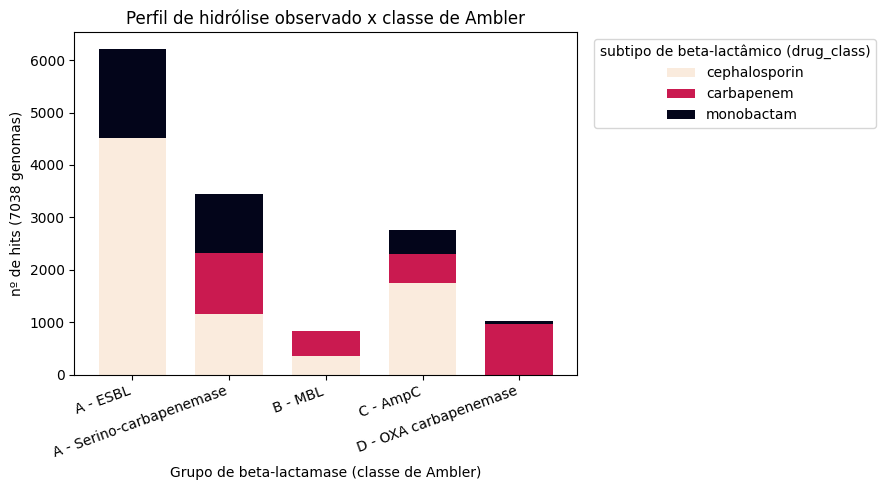

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
tabela_empilhada.plot(kind="bar", stacked=True, ax=ax, colormap="rocket_r", width=0.7)
ax.set_ylabel(f"n\u00ba de hits ({len(dataset.metadata)} genomas)")
ax.set_xlabel("Grupo de beta-lactamase (classe de Ambler)")
ax.set_title("Perfil de hidr\u00f3lise observado x classe de Ambler")
ax.legend(title="subtipo de beta-lact\u00e2mico (drug_class)", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

## 7. Matriz por especie

In [37]:
especie_por_amostra = dataset.metadata["Species"]
especie_por_amostra

sample
GCA_000172875.1       Enterococcus faecium
GCA_000188755.2           Escherichia coli
GCA_000188815.2           Escherichia coli
GCA_000188875.2           Escherichia coli
GCA_000208825.1           Aeromonas caviae
                            ...           
GCF_002018965.1    Acinetobacter baumannii
GCF_002018995.1    Acinetobacter baumannii
GCF_002019005.1    Acinetobacter baumannii
GCF_002019025.1    Acinetobacter baumannii
GCF_002019035.1    Acinetobacter baumannii
Name: Species, Length: 7038, dtype: object

In [38]:
especie_do_hit = bl_hits["sample_id"].map(especie_por_amostra).rename("Species")
especie_do_hit.head()

49     Escherichia coli
83     Escherichia coli
108    Escherichia coli
120    Escherichia coli
147    Escherichia coli
Name: Species, dtype: object

In [39]:
especie_grupo = pd.crosstab(especie_do_hit, bl_hits["bl_group"])
especie_grupo = especie_grupo.reindex(columns=list(GRUPOS_BL.keys()), fill_value=0)
especie_grupo.loc[especie_grupo.sum(axis=1).sort_values(ascending=False).index]


bl_group,A - ESBL,A - Serino-carbapenemase,B - MBL,C - AmpC,D - OXA carbapenemase
Species,,,,,
Klebsiella pneumoniae,3191,972,128,1,4
Acinetobacter baumannii,168,2,35,434,867
Escherichia coli,501,32,15,631,1
Pseudomonas aeruginosa,26,57,131,462,0
Neisseria gonorrhoeae,227,0,0,0,0
...,...,...,...,...,...
Pseudomonas chlororaphis,0,0,1,0,0
Pseudomonas asiatica,0,0,1,0,0
Ralstonia insidiosa,0,0,0,0,1


In [42]:
import seaborn as sns

<Axes: xlabel='bl_group', ylabel='Species'>

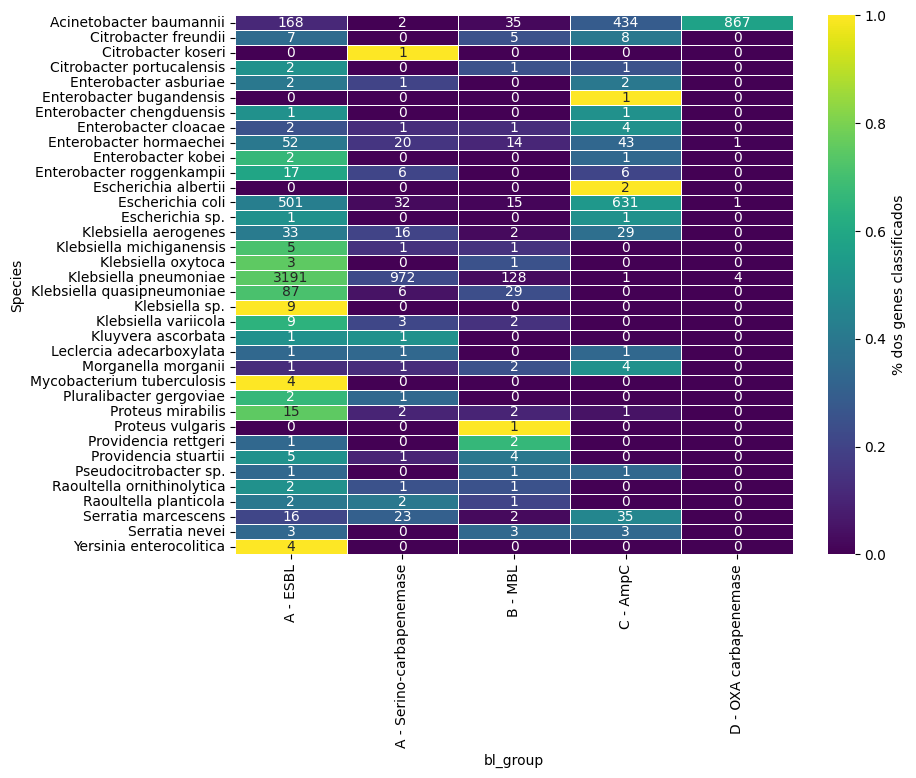

In [54]:
especies_who = metadata[metadata["WHO_Priority"].isin(["Critical"])]["Species"].unique()
especie_grupo_filtrado = especie_grupo.loc[especie_grupo.index.isin(especies_who)]

especie_grupo_filtrado

colunas_grupo = especie_grupo_filtrado.columns.tolist()

n_total_por_especie = especie_grupo_filtrado.sum(axis=1)
especie_grupo_pct = especie_grupo_filtrado.div(n_total_por_especie, axis=0)

anotacao = especie_grupo_filtrado.astype(int).astype(str)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    especie_grupo_pct,
    cmap="viridis", annot=anotacao, fmt="",
    linewidths=0.5, linecolor="white",
    vmin=0, vmax=1,
    cbar_kws={"label": "% dos genes classificados"},
    ax=ax,
)

In [52]:
ampc_com_carbapenem = dataset.resistome[
    (dataset.resistome["ambler_class"] == "C") & dataset.resistome["tem_carbapenem"]
]
print(ampc_com_carbapenem["gene_clean"].value_counts().head(15))

gene_clean
PDC-5      138
PDC-3       66
PDC-35      46
PDC-16      41
PDC-1       34
CMY-2       32
PDC-68      19
PDC-8       18
PDC-24      15
ACT-157      9
PDC-19a      7
PDC-11       7
PDC-109      6
PDC-12       6
PDC-14       6
Name: count, dtype: int64
